## 03 — Visualizations

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../output/anes_clean.csv")

### Viz 1 — Partisan gap over time with Gini overlay

In [13]:
# Census Bureau Historical Income Table H-4
# https://www.census.gov/data/tables/time-series/demo/income-poverty/historical-income-households.html
gini_df = pd.read_csv("../data/gini_census.csv")

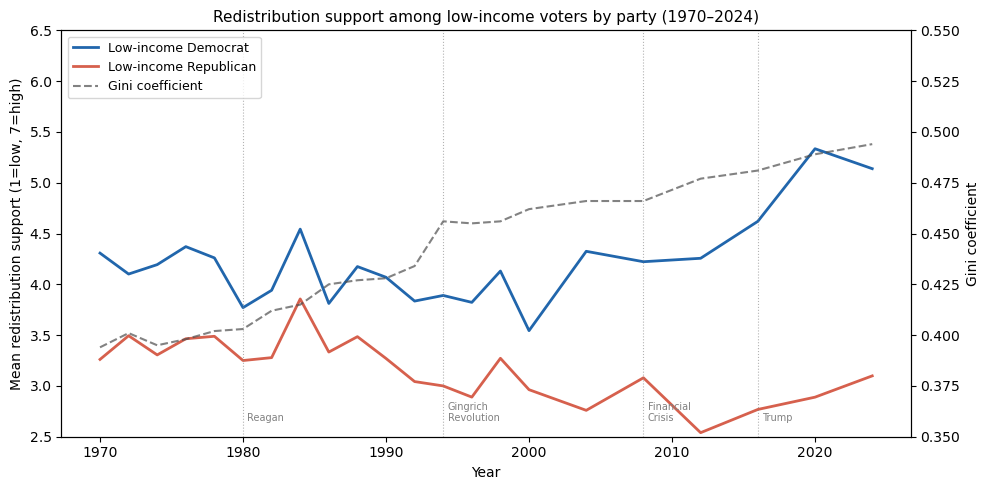

In [14]:
lowinc = df[df['lowinc'] & df['party3'].isin(['Democrat','Republican'])]
ts = (lowinc.groupby(['year','party3'])['redist']
           .mean().unstack().reset_index()
           .merge(gini_df, on='year', how='left'))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ts['year'], ts['Democrat'],   color='#2166ac', lw=2, label='Low-income Democrat')
ax1.plot(ts['year'], ts['Republican'], color='#d6604d', lw=2, label='Low-income Republican')
ax1.set_ylabel("Mean redistribution support (1=low, 7=high)")
ax1.set_ylim(2.5, 6.5)
ax1.set_xlabel("Year")

# gini on secondary axis
ax2 = ax1.twinx()
ax2.plot(ts['year'], ts['gini'], color='#4d4d4d', lw=1.5, ls='--', alpha=0.7, label='Gini coefficient')
ax2.set_ylabel("Gini coefficient")
ax2.set_ylim(0.35, 0.55)

events = {1980:'Reagan', 1994:'Gingrich\nRevolution', 2008:'Financial\nCrisis', 2016:'Trump'}
for yr, label in events.items():
    ax1.axvline(yr, color='gray', lw=0.8, ls=':', alpha=0.6)
    ax1.text(yr+0.3, 2.65, label, fontsize=7, color='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
ax1.set_title("Redistribution support among low-income voters by party (1970–2024)", fontsize=11)
plt.tight_layout()
plt.savefig("../output/viz1_gini_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

### Viz 2 — Small multiples: redistribution by income x party, by decade

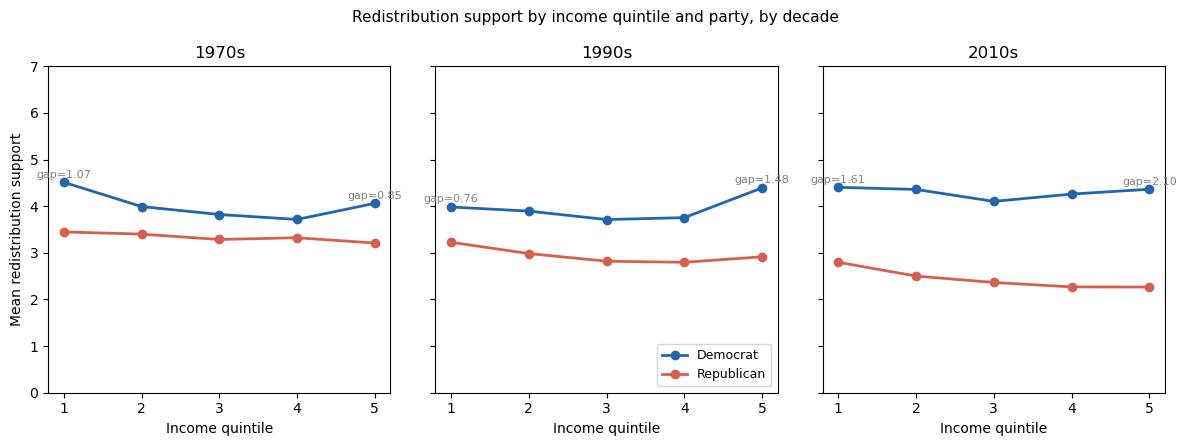

In [15]:
decade_map = {'1970s':(1970,1979), '1990s':(1990,1999), '2010s':(2010,2019)}
parties = ['Democrat','Republican']
colors  = {'Democrat':'#2166ac','Republican':'#d6604d'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True)
for ax, (dlabel, (y0,y1)) in zip(axes, decade_map.items()):
    sub = df[(df['year']>=y0) & (df['year']<=y1) & df['party3'].isin(parties)]
    for p in parties:
        grp = sub[sub['party3']==p].groupby('income')['redist'].mean()
        ax.plot(grp.index, grp.values, marker='o', color=colors[p], label=p, lw=2)

    # annotate gap at lowest and highest income quintile
    for q in [1, 5]:
        vals = {p: sub[sub['party3']==p].groupby('income')['redist'].mean().get(q, np.nan) for p in parties}
        if not any(np.isnan(v) for v in vals.values()):
            gap = abs(vals['Democrat'] - vals['Republican'])
            ax.annotate(f"gap={gap:.2f}", xy=(q, max(vals.values())+0.1), ha='center', fontsize=8, color='gray')

    ax.set_title(dlabel)
    ax.set_xlabel("Income quintile")
    ax.set_xticks([1,2,3,4,5])
    ax.set_ylim(0, 7)

axes[0].set_ylabel("Mean redistribution support")
axes[1].legend(loc='lower right', fontsize=9)
fig.suptitle("Redistribution support by income quintile and party, by decade", fontsize=11)
plt.tight_layout()
plt.savefig("../output/viz2_small_multiples.png", dpi=150, bbox_inches='tight')
plt.show()